In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
from pathlib import Path

notebook_path = Path().absolute()
sys.path.append(str(notebook_path.parent))

In [3]:
import torch
from tqdm import tqdm
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from neural_controllers import NeuralController
from utils import newton_dataset
from tqdm import tqdm
import matplotlib.pyplot as plt
import math
from scipy.linalg import eigh
from scipy.stats import entropy

from transformers import logging
logging.set_verbosity_error() # Only show errors

torch.manual_seed(0)
torch.cuda.manual_seed(0)
np.random.seed(0)

In [4]:
custom_cache_dir = "/scratch/bbjr/skarmakar/huggingface"

model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"
model_name='llama_3_8b_it'

language_model = AutoModelForCausalLM.from_pretrained(
    model_id, 
    device_map="auto", 
    cache_dir=custom_cache_dir,
)

use_fast_tokenizer = "LlamaForCausalLM" not in language_model.config.architectures
tokenizer = AutoTokenizer.from_pretrained(
    model_id, 
    use_fast=use_fast_tokenizer, 
    padding_side="left", 
    legacy=False,
)

# tokenizer.pad_token_id = 0 if tokenizer.pad_token_id is None else tokenizer.pad_token_id
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [5]:
def find_lingering_forward_hooks(model):
    lingering_hooks = []
    for name, module in model.named_modules():
        if module._forward_hooks:
            hook_info = (name, 'forward')
            lingering_hooks.append(hook_info)
            print(f"Warning: Found {len(module._forward_hooks)} lingering 'forward' hook(s) on module: {name}")

        if module._forward_pre_hooks:
            hook_info = (name, 'forward_pre')
            lingering_hooks.append(hook_info)
            print(f"Warning: Found {len(module._forward_pre_hooks)} lingering 'forward_pre' hook(s) on module: {name}")
            
    if not lingering_hooks:
        print("Success: No lingering forward hooks found in the model.")
        
    return lingering_hooks

In [6]:
rfm_iters = 16
batch_size = 8
n_components = 300
# n_components = 5
# energy = 0.99

In [7]:
# path = '../directions/stable/emotions_300'
# path = '../directions/stable/emotions_300_2'
# path = '../directions/stable/isaac_cam_300'
# path = '../directions/stable/isaac_cam_300_2'
# path = '../directions/stable/isaac_cam_300_3_0'

# path = '../directions/stable/isaac_cam_300_ite_d15_0'
# path = '../directions/stable/isaac_cam_300_ite_d1_0'
# path = '../directions/stable/isaac_cam_300_ite_d5_0'

# path = '../directions/stable/isaac_cam_old'

# path = "/scratch/bbjr/skarmakar/dementia/ckpt/isaac_cam_300_itea_d1_0"
path = "../directions/stable/isaac_cam_300_itea_d1_0"

concept_types = ["Cam", "Isaac"]
# concept_types = ["love", "hate"]

controllers = {}

for concept_type in concept_types:
    
    controller = NeuralController(
        language_model,
        tokenizer,
        rfm_iters=rfm_iters,
        batch_size=batch_size,
        control_method='rfm',
        # control_method='logistic',
        n_components=n_components,
        # energy=0.98,
    )
    
    other_type = [k for k in concept_types if k!=concept_type][0]
    
    controller.load(concept=f'{concept_type}', model_name=model_name, path=path)
    
    controllers[concept_type] = controller
    
    # break

n_components: 300
Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 16
forward_batch_size   : 8
M_batch_size         : 2048
n_components         : 300



/u/skarmakar1/miniconda3/envs/neucon/lib/python3.10/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


Detector found
n_components: 300
Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 16
forward_batch_size   : 8
M_batch_size         : 2048
n_components         : 300

Detector found


In [8]:
print(len(controllers["Cam"].directions[-1]))
print(controllers["Cam"].directions[-1][0].shape)

15
torch.Size([300, 4096])


In [9]:
top_dirs_cam = {}

for hl in controllers["Cam"].directions:
    top_dirs_cam[hl] = torch.stack([o[0] for o in controllers["Cam"].directions[hl]])

In [10]:
print(top_dirs_cam.keys())
print(top_dirs_cam[-1].shape)
print(type(top_dirs_cam[-1]))
print(type(top_dirs_cam[-1][0]))
print(top_dirs_cam[-1][0].shape)

dict_keys([-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31])
torch.Size([15, 4096])
<class 'torch.Tensor'>
<class 'torch.Tensor'>
torch.Size([4096])


In [ ]:
# def top_k(s, e):
#     trace_total = s.sum()
#     idx = torch.argsort(s, descending=True)
#     evals_sorted = s[idx]
#     cumsum = torch.cumsum(evals_sorted, dim=0)

#     target = e * trace_total
#     m = int((cumsum >= target).nonzero()[0][0]) + 1

#     return m

In [ ]:
# for i in range(-1, -32, -1):
#     print(i, controllers["Cam"].directions[i].shape, top_k(controllers["Cam"].directions_importance[i], 0.98))

In [ ]:
# for i in range(-1, -32, -1):
#     print(i, controllers["Isaac"].directions[i].shape, top_k(controllers["Isaac"].directions_importance[i], 0.98))

In [17]:
# import numpy as np
# from scipy.linalg import eigh
# from scipy.stats import entropy

def spectral_indicators(M, tau=0.9, eps=1e-12, clip_neg=True):
    w, V = eigh(M, lower=True, check_finite=False)
    
    if clip_neg:
        w = np.clip(w, 0.0, None)
    
    lam = np.flip(w)
    
    tr = lam.sum()
    lam2_sum = np.dot(lam, lam)
    lam_max = lam[0] if lam.size > 0 else 0.0
    lam_min = lam[-1] if lam.size > 0 else 0.0

    # Condition number (2-norm)
    cond2 = (lam_max / max(lam_min, eps)) if lam.size > 0 else np.nan

    # Stable rank: ||M||_F^2 / ||M||_2^2 = (sum lam_i^2) / lam_max^2
    stable_rank = (lam2_sum / max(lam_max**2, eps)) if lam_max > 0 else 0.0

    # Participation ratio: (sum lam)^2 / sum lam^2
    pr = (tr**2 / max(lam2_sum, eps)) if lam2_sum > 0 else 0.0

    # # Entropic effective rank (eRank)
    # if tr > 0:
    #     p = lam / tr
    #     p_safe = np.where(p > 0, p, 1.0)
    #     H = -np.sum(p * np.log(p_safe))
    #     erank = float(np.exp(H))
    # else:
    #     erank = 0.0

    # Entropic effective rank (eRank)
    if tr > 0:
        p = lam / tr
        H = entropy(p, base=np.e)
        erank = float(np.exp(H))
    else:
        erank = 0.0

    # Cumulative energy and tau-based k
    if tr > 0:
        cum = np.cumsum(lam) / tr
        k_tau = int(np.searchsorted(cum, tau) + 1)
        cumulative_energy = cum
    else:
        k_tau = 0
        cumulative_energy = np.zeros_like(lam)

    return {
        "eigenvalues_desc": lam,
        "condition_number_2": float(cond2),
        "stable_rank": float(stable_rank),
        "participation_ratio": float(pr),
        "effective_rank_entropy": float(erank),
        "cumulative_energy": cumulative_energy,
        "k_at_tau": k_tau,
        "eigenvectors": V[:, ::-1],  # columns match descending lam
    }

In [18]:
def find_min_ind(l, v):
    for i in range(len(l)):
        if l[i] < v:
            return i

Layer: -31, Condition Number: 8.38e+13, Stable Rank: 1.04, Top k (0.8): 3, Participation Ratio: 2.34, eRank Entropy: 6.01
[83.82931    11.673415    9.011097    3.7226148   2.4325266   1.2434279
  1.0961266   0.9855911   0.97223705  0.84183955  0.7453711   0.66903335
  0.6027529   0.5828335   0.5373581   0.52516454  0.49737057  0.48231262
  0.45558298  0.38067493  0.37499323  0.3576957   0.3456453   0.34233436
  0.31447095]


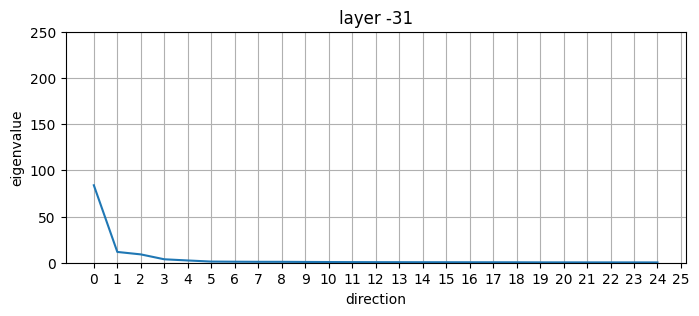

Layer: -30, Condition Number: 4.61e+13, Stable Rank: 1.27, Top k (0.8): 7, Participation Ratio: 4.54, eRank Entropy: 12.26
[46.10795    19.71157    11.611629    5.971895    2.3393052   2.164528
  1.8371531   1.3078288   0.9428581   0.90369886  0.8069824   0.6978509
  0.6765996   0.5749284   0.5490566   0.54268265  0.47599834  0.43579024
  0.41080377  0.3962833   0.37080002  0.34205502  0.3111878   0.30647123
  0.28128698]


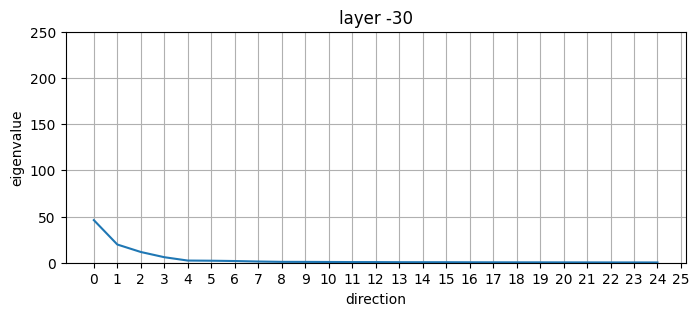

Layer: -29, Condition Number: 3.02e+14, Stable Rank: 1.03, Top k (0.8): 2, Participation Ratio: 1.72, eRank Entropy: 2.73
[3.0194717e+02 4.0689713e+01 2.6711916e+01 1.1039580e+01 5.2548265e+00
 3.7467415e+00 2.9916949e+00 2.2375262e+00 1.6665484e+00 1.4889475e+00
 7.7907556e-01 5.3331548e-01 4.1726637e-01 2.8901365e-01 2.8564325e-01
 1.6801994e-01 1.4696926e-01 1.3899834e-01 1.3047616e-01 9.3874417e-02
 7.5318612e-02 6.3734829e-02 5.2962027e-02 4.5553219e-02 3.8770713e-02]


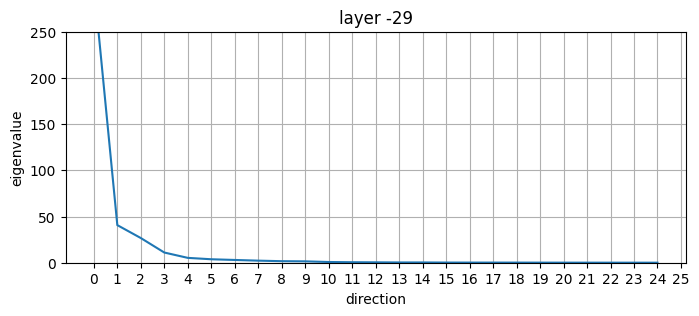

Layer: -28, Condition Number: 1.19e+14, Stable Rank: 1.07, Top k (0.8): 28, Participation Ratio: 5.14, eRank Entropy: 23.09
[119.438156   21.552519   16.520937    7.59794     6.5269427   4.708898
   4.374612    3.7563004   3.5985837   3.3250208   3.1587718   2.6798594
   2.5399544   2.2608013   2.1156478   2.0659928   2.0025558   1.9632007
   1.8697977   1.7709067   1.6395121   1.5206063   1.4790379   1.4530993
   1.4238495]


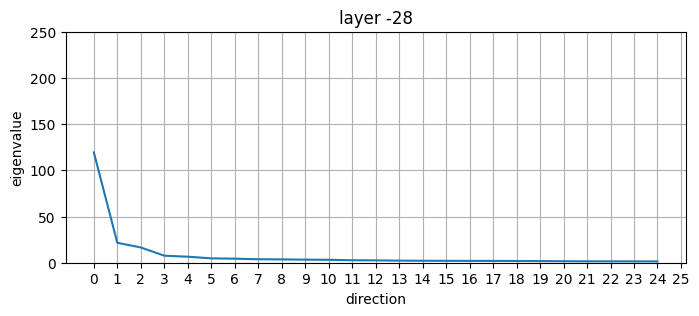

Layer: -27, Condition Number: 3.39e+14, Stable Rank: 1.00, Top k (0.8): 1, Participation Ratio: 1.00, eRank Entropy: 1.00
[3.3923669e+02 8.3160354e-03 2.3317121e-03 1.3149033e-03 6.0100458e-04
 4.4196803e-04 2.3282143e-04 1.8042834e-04 1.3551030e-04 1.2015957e-04
 9.5106312e-05 9.2736431e-05 6.0284583e-05 4.2582382e-05 4.1541112e-05
 1.7020504e-05 1.4141604e-05 1.2753473e-05 1.1396134e-05 1.0332966e-05
 9.4298057e-06 7.5405692e-06 7.2945804e-06 6.6980615e-06 5.0325161e-06]


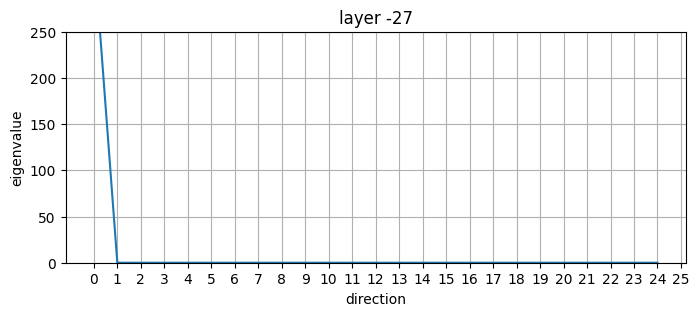

Layer: -26, Condition Number: 2.67e+14, Stable Rank: 1.00, Top k (0.8): 1, Participation Ratio: 1.14, eRank Entropy: 1.42
[2.6716479e+02 6.8891168e+00 5.1983685e+00 1.6632127e+00 1.1046282e+00
 8.2357764e-01 4.8975915e-01 3.9572975e-01 3.3962351e-01 1.7310920e-01
 1.5054102e-01 1.0975662e-01 8.1052117e-02 7.6531492e-02 6.6804528e-02
 5.2257299e-02 4.2343788e-02 2.9298715e-02 2.6543196e-02 2.0622786e-02
 1.8624183e-02 1.8089082e-02 1.4780610e-02 1.1221717e-02 9.8649887e-03]


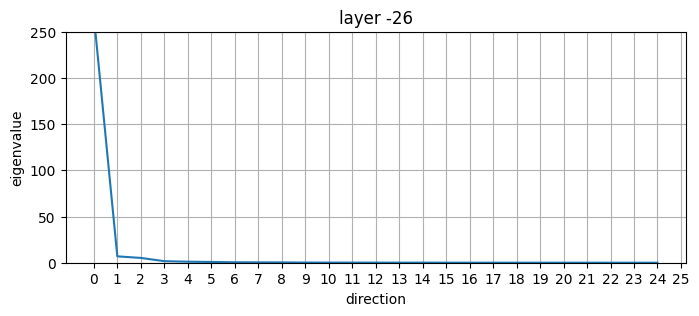

Layer: -25, Condition Number: 1.39e+14, Stable Rank: 1.02, Top k (0.8): 12, Participation Ratio: 2.80, eRank Entropy: 11.21
[138.53127     12.508431     9.842895     5.492454     4.141971
   3.2260945    3.0827248    2.7118478    2.432787     2.3377128
   2.0772586    1.8514148    1.7713431    1.5040175    1.3933166
   1.2911105    1.2116885    1.1549153    1.0157603    0.91668266
   0.9093602    0.8481292    0.8100739    0.769234     0.7107346 ]


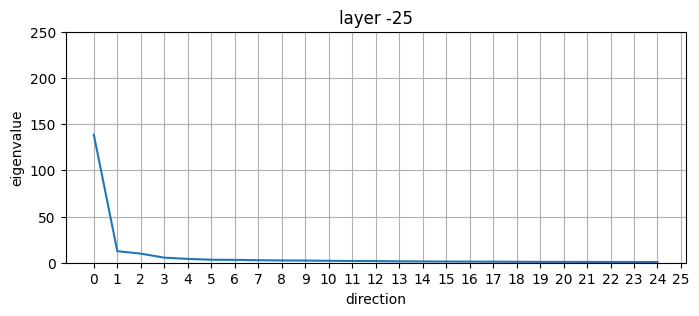

Layer: -24, Condition Number: 2.07e+14, Stable Rank: 1.02, Top k (0.8): 2, Participation Ratio: 1.81, eRank Entropy: 3.45
[2.0659773e+02 1.9766273e+01 1.0033039e+01 8.5532455e+00 6.4084444e+00
 5.7322841e+00 4.7379227e+00 3.5876637e+00 2.8872342e+00 2.0518389e+00
 1.6578784e+00 1.1751735e+00 8.9843327e-01 7.6615465e-01 6.3749200e-01
 5.5327135e-01 4.1080940e-01 3.9897844e-01 3.3647710e-01 3.0886292e-01
 2.6805362e-01 2.4478097e-01 1.8543833e-01 1.7468020e-01 1.6104051e-01]


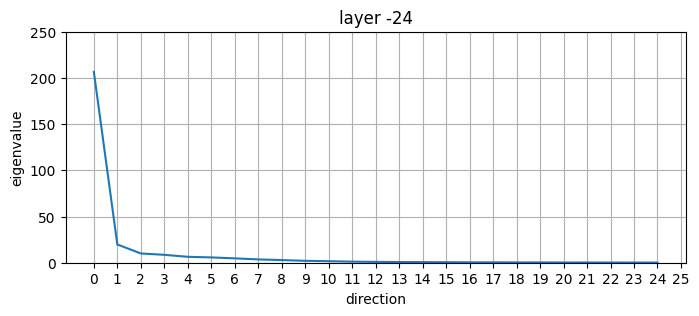

Layer: -23, Condition Number: 7.10e+13, Stable Rank: 1.01, Top k (0.8): 1, Participation Ratio: 1.28, eRank Entropy: 1.60
[7.0953773e+01 6.6394672e+00 1.9850248e+00 8.6122710e-01 1.5295951e-01
 2.6288299e-02 1.3100513e-03 4.6554655e-05 4.0758372e-05 4.0215280e-05
 3.0141207e-05 2.8754490e-05 1.8273640e-05 1.6662727e-05 1.5146234e-05
 5.5064193e-06 1.6760680e-06 1.3652472e-06 1.1216310e-06 1.0040460e-06
 8.9248158e-07 8.1613325e-07 6.8777956e-07 6.7524888e-07 6.7501890e-07]


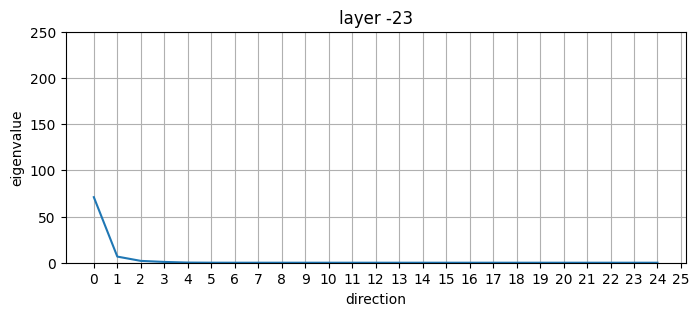

Layer: -22, Condition Number: 1.50e+14, Stable Rank: 1.01, Top k (0.8): 5, Participation Ratio: 1.92, eRank Entropy: 6.37
[149.54205      8.953498     4.236621     2.7493792    2.004364
   1.6370101    1.4433615    1.4207488    1.303009     1.2028718
   0.9932252    0.95940506   0.8986038    0.80189455   0.76158047
   0.72130334   0.6690297    0.6433605    0.56904435   0.55153954
   0.5289333    0.49849674   0.4668235    0.46361807   0.4562163 ]


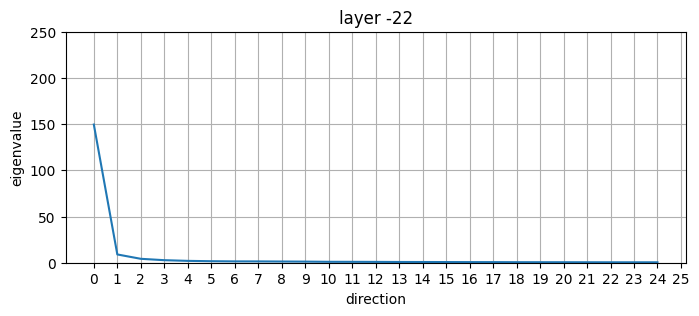

Layer: -21, Condition Number: 1.78e+14, Stable Rank: 1.01, Top k (0.8): 8, Participation Ratio: 2.20, eRank Entropy: 8.09
[178.32683     10.644778     7.376901     5.2450476    3.712826
   3.105417     2.579143     2.379329     2.0334353    1.6785158
   1.5676329    1.4315429    1.262459     1.1992542    1.0674013
   1.0181231    0.95636886   0.9163939    0.85907173   0.8547384
   0.8039661    0.76333797   0.7372747    0.7168464    0.66423714]


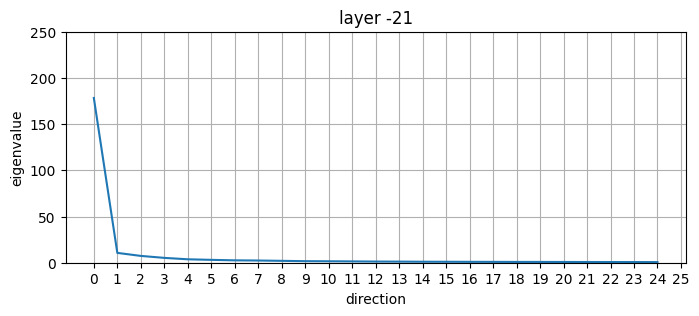

Layer: -20, Condition Number: 1.49e+14, Stable Rank: 1.01, Top k (0.8): 2, Participation Ratio: 1.80, eRank Entropy: 3.66
[149.15964     12.782958     6.449478     5.9174247    4.3963804
   3.2287946    2.4655683    2.2416935    2.1137626    1.4975889
   1.4221665    1.0410072    0.9410335    0.8242846    0.70318353
   0.62959075   0.5470116    0.46971008   0.42025837   0.3932639
   0.3275283    0.30804646   0.28215948   0.24485286   0.22191423]


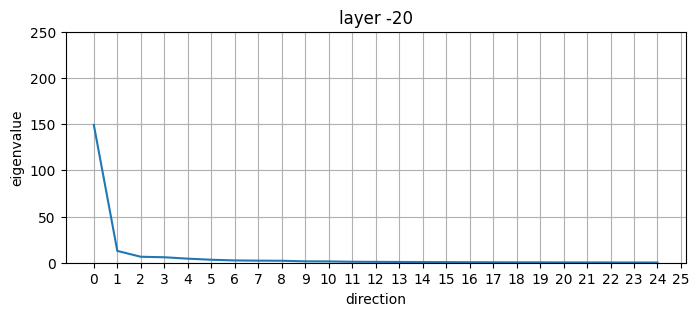

Layer: -19, Condition Number: 4.29e+13, Stable Rank: 1.14, Top k (0.8): 9, Participation Ratio: 4.71, eRank Entropy: 11.19
[42.928345   11.693616    6.005022    4.858347    4.230514    3.6054182
  3.1430748   2.5005045   2.218635    2.0030305   1.7412044   1.4401119
  1.3189298   1.1893002   1.0155      0.9445032   0.841129    0.7503516
  0.66714025  0.5376397   0.49391052  0.42876068  0.38894704  0.37500918
  0.30752817]


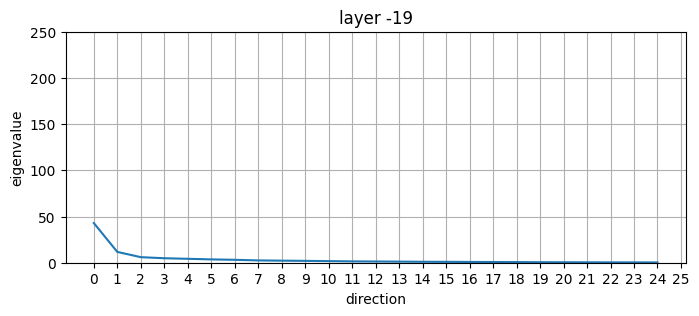

Layer: -18, Condition Number: 1.60e+14, Stable Rank: 1.01, Top k (0.8): 13, Participation Ratio: 2.23, eRank Entropy: 9.09
[159.93973     14.125646     3.698483     2.3508964    2.169898
   1.6539047    1.6357032    1.4403324    1.3719112    1.2912488
   1.2646328    1.136098     1.0909573    1.0106478    0.95502925
   0.9159609    0.8853277    0.8576288    0.79392433   0.75119746
   0.7143965    0.69250095   0.66004086   0.6469314    0.59942865]


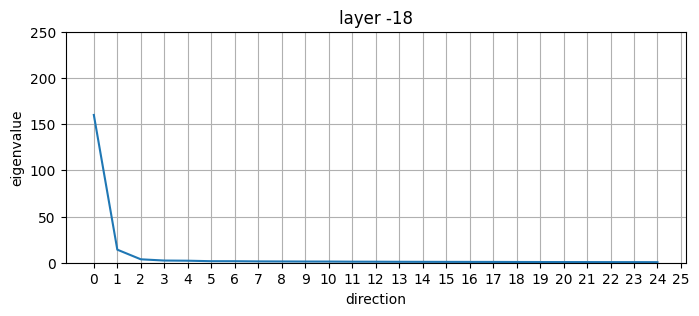

Layer: -17, Condition Number: 2.68e+14, Stable Rank: 1.00, Top k (0.8): 3, Participation Ratio: 1.70, eRank Entropy: 5.04
[268.21448      8.0431185    6.1456923    3.918816     3.4618044
   2.8042421    2.3383923    2.2014668    2.0592296    1.7624074
   1.6388546    1.5349333    1.4835954    1.3967433    1.1693339
   1.1118101    1.0299003    0.9612896    0.8750475    0.82205194
   0.7703642    0.7469462    0.6945783    0.6844985    0.62849027]


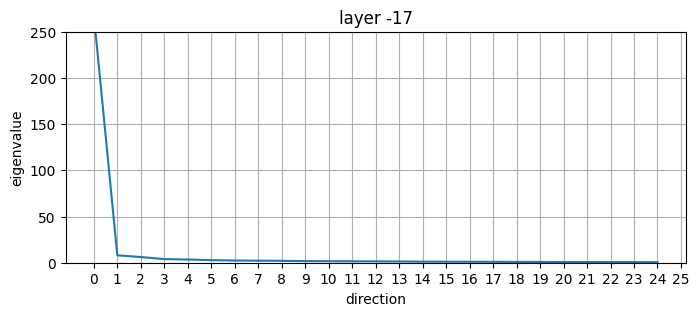

Layer: -16, Condition Number: 1.99e+14, Stable Rank: 1.00, Top k (0.8): 4, Participation Ratio: 1.70, eRank Entropy: 4.97
[198.66855      4.3358197    3.8874426    3.209497     2.9515955
   2.4034755    2.2777078    1.7566274    1.6429627    1.5676773
   1.4126328    1.3236492    1.1727251    1.0448207    0.95538855
   0.8344855    0.807016     0.7829038    0.7599182    0.7172886
   0.67080134   0.64667726   0.61707985   0.579449     0.55846447]


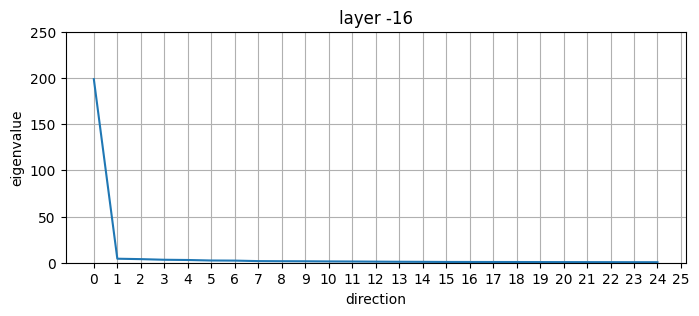

Layer: -15, Condition Number: 1.95e+14, Stable Rank: 1.01, Top k (0.8): 4, Participation Ratio: 1.84, eRank Entropy: 5.18
[194.92758      9.409457     5.51551      4.437482     3.9693594
   3.5302198    3.0048592    2.7141192    2.2830858    1.9211843
   1.7779729    1.6321934    1.4923851    1.2778056    1.2411093
   1.0949856    0.9418927    0.86270386   0.85278904   0.7795597
   0.70856184   0.6221336    0.5767583    0.54437244   0.52450585]


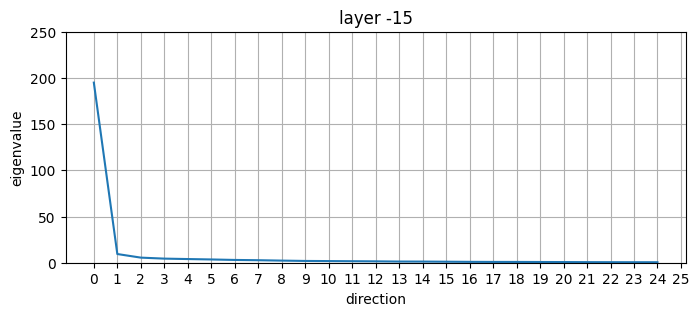

Layer: -14, Condition Number: 1.08e+13, Stable Rank: 2.04, Top k (0.8): 107, Participation Ratio: 55.75, eRank Entropy: 145.12
[10.845267   4.227244   3.2684157  3.2219968  2.8770459  2.691382
  2.394288   2.179918   1.9765468  1.9599723  1.7944977  1.6804594
  1.5462341  1.51395    1.4858996  1.360483   1.2906741  1.2588798
  1.2181336  1.184111   1.1368572  1.1052333  1.0685657  1.0278099
  0.9901146]


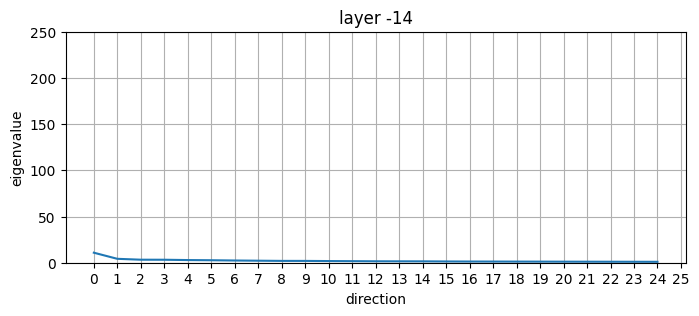

Layer: -13, Condition Number: 2.57e+13, Stable Rank: 1.39, Top k (0.8): 3, Participation Ratio: 3.18, eRank Entropy: 3.83
[2.5701893e+01 1.2480643e+01 8.4245424e+00 4.4134226e+00 2.9037240e+00
 6.0981998e-05 1.2817230e-05 9.8446699e-06 8.5782412e-06 7.3387682e-06
 7.3067285e-06 5.7113170e-06 4.7459284e-06 3.8461685e-06 1.2205395e-06
 9.3251589e-07 8.4392497e-07 7.1288230e-07 6.2966689e-07 5.2481226e-07
 5.1170161e-07 4.9548544e-07 3.6740335e-07 3.4987482e-07 3.3244660e-07]


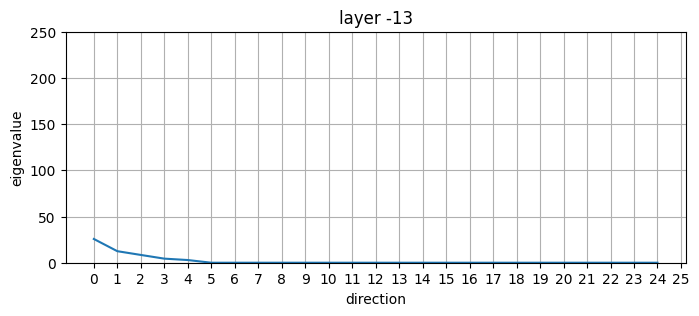

Layer: -12, Condition Number: 8.15e+13, Stable Rank: 1.07, Top k (0.8): 5, Participation Ratio: 2.93, eRank Entropy: 5.81
[81.50947    11.971548   10.388936    8.478313    7.702125    6.3409214
  4.4885163   2.7625463   2.36029     1.8753434   1.1100904   0.90436333
  0.701693    0.5561673   0.4453777   0.35501283  0.3189414   0.22840506
  0.18372324  0.15626161  0.12398218  0.11125966  0.10509769  0.09810239
  0.09122475]


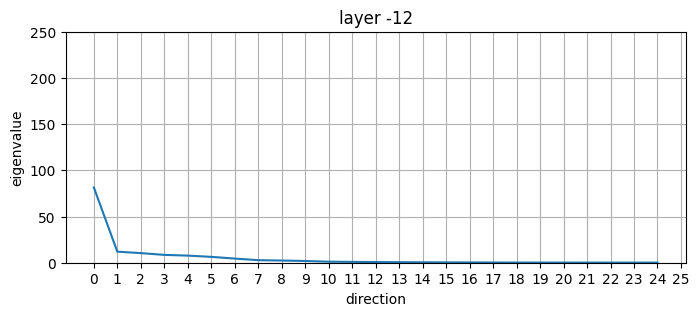

Layer: -11, Condition Number: 4.42e+12, Stable Rank: 3.92, Top k (0.8): 125, Participation Ratio: 93.53, eRank Entropy: 184.16
[4.421061   2.5492756  2.3235023  1.8416069  1.7326888  1.5048355
 1.4365903  1.4096915  1.3536758  1.3419123  1.2261941  1.1664729
 1.1287935  1.1015778  1.0421244  1.0260336  0.97346073 0.9365529
 0.8860469  0.8631991  0.8034743  0.7932183  0.78857595 0.7690311
 0.7469485 ]


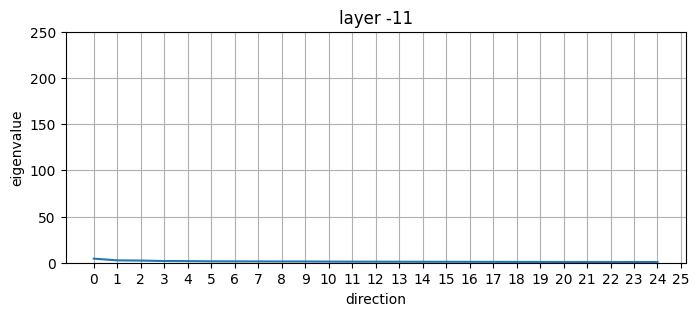

Layer: -10, Condition Number: 5.66e+12, Stable Rank: 4.85, Top k (0.8): 135, Participation Ratio: 113.71, eRank Entropy: 204.12
[5.662059  2.899607  2.6674106 2.6238856 2.4263728 2.3585603 2.2383387
 2.0940425 2.0599813 1.9505136 1.8245939 1.7201098 1.6402007 1.6201879
 1.5341599 1.5254934 1.4637338 1.4413171 1.3937247 1.3632238 1.3367932
 1.2857136 1.2587097 1.1969886 1.1897596]


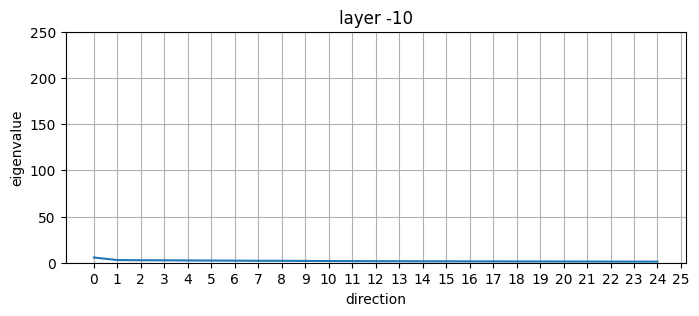

Layer: -9, Condition Number: 1.29e+14, Stable Rank: 1.01, Top k (0.8): 2, Participation Ratio: 1.73, eRank Entropy: 3.16
[1.28556107e+02 1.08158827e+01 7.11055470e+00 6.28447962e+00
 4.40777397e+00 2.93969727e+00 2.13165069e+00 1.37893045e+00
 1.17247379e+00 9.35280979e-01 6.45543873e-01 6.08812988e-01
 4.77735013e-01 4.02611762e-01 3.07531089e-01 2.33214736e-01
 2.02341408e-01 1.76189929e-01 1.53131023e-01 1.51684597e-01
 1.30413353e-01 1.20961346e-01 9.78427231e-02 8.96502584e-02
 7.99591765e-02]


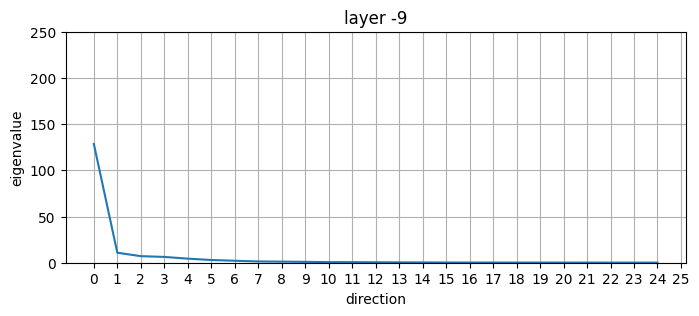

Layer: -8, Condition Number: 3.22e+14, Stable Rank: 1.00, Top k (0.8): 1, Participation Ratio: 1.00, eRank Entropy: 1.00
[3.2224820e+02 5.5719603e-02 2.8206722e-03 2.2575304e-04 1.9747294e-04
 1.4343609e-04 1.3288298e-04 1.1019282e-04 9.8086297e-05 8.8470886e-05
 7.4908960e-05 5.1711875e-05 4.8646383e-05 2.0649049e-05 1.8839055e-05
 7.8658140e-06 7.4184254e-06 6.9957737e-06 6.4534502e-06 5.8644800e-06
 5.1093375e-06 5.1037609e-06 4.1518547e-06 2.8018926e-06 2.5656873e-06]


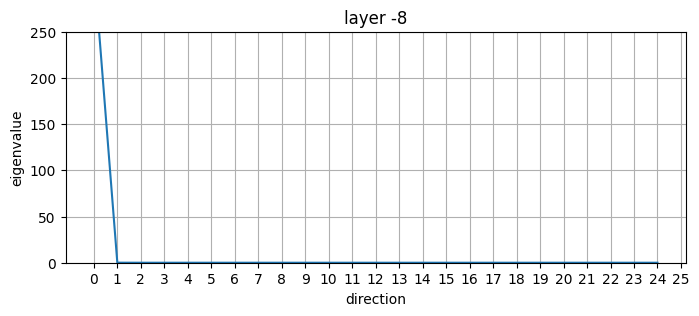

Layer: -7, Condition Number: 7.99e+13, Stable Rank: 1.00, Top k (0.8): 1, Participation Ratio: 1.01, eRank Entropy: 1.03
[7.9938438e+01 3.0692542e-01 3.9980146e-03 7.6342381e-05 7.2446339e-05
 6.5324690e-05 6.2295869e-05 5.8984842e-05 5.5742268e-05 4.7408314e-05
 4.2302374e-05 3.4450080e-05 2.7014285e-05 1.9570965e-05 1.2837416e-05
 2.9958974e-06 7.3403771e-07 7.0550652e-07 6.0592987e-07 4.3375053e-07
 3.9202388e-07 3.7060843e-07 3.4679164e-07 2.8520714e-07 2.7598679e-07]


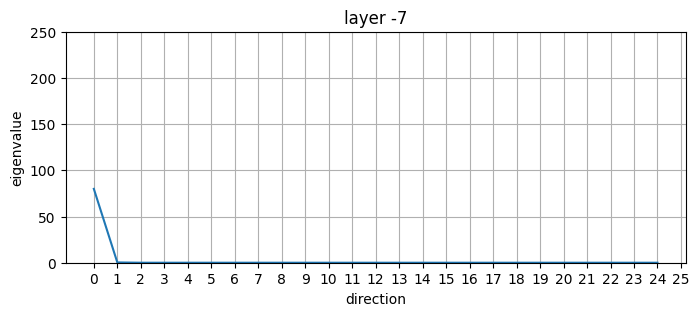

Layer: -6, Condition Number: 2.16e+14, Stable Rank: 1.00, Top k (0.8): 1, Participation Ratio: 1.01, eRank Entropy: 1.04
[2.1577029e+02 2.6833501e-01 1.6061291e-01 1.0654654e-01 6.0117062e-02
 4.5275137e-02 3.0351317e-02 2.6952785e-02 2.4657272e-02 1.7025778e-02
 1.4806859e-02 1.3522626e-02 1.2837271e-02 1.0619493e-02 7.6661282e-03
 5.3550759e-03 5.0234473e-03 4.7510955e-03 4.1628303e-03 3.6429402e-03
 3.2204704e-03 3.0227858e-03 2.7024806e-03 2.5137328e-03 2.2284777e-03]


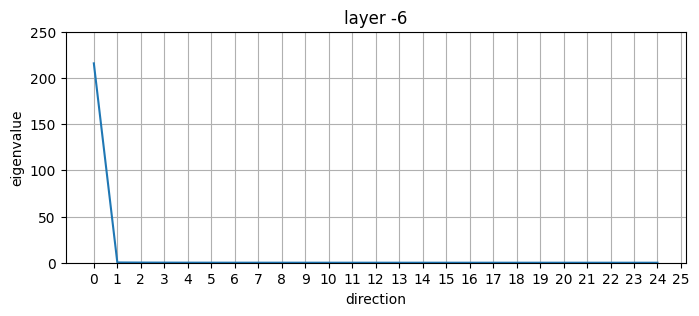

Layer: -5, Condition Number: 2.83e+14, Stable Rank: 1.00, Top k (0.8): 1, Participation Ratio: 1.00, eRank Entropy: 1.01
[2.8306903e+02 3.5443237e-01 5.1348735e-02 1.3472576e-02 8.9205205e-03
 6.5435367e-03 5.4259906e-03 4.8002675e-03 4.2748982e-03 3.5404153e-03
 3.2105490e-03 2.5702289e-03 2.2850635e-03 2.1074547e-03 1.6051934e-03
 1.5010190e-03 1.3316754e-03 1.1798484e-03 1.0315748e-03 1.0135598e-03
 8.1650598e-04 7.5225555e-04 6.9962681e-04 6.0192356e-04 5.7273393e-04]


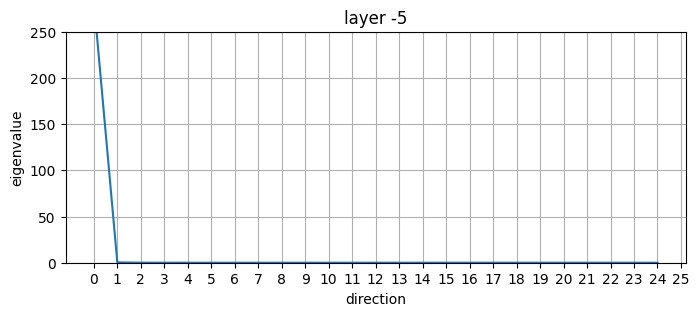

Layer: -4, Condition Number: 2.96e+14, Stable Rank: 1.00, Top k (0.8): 1, Participation Ratio: 1.24, eRank Entropy: 2.24
[296.20374      2.5902064    1.6285778    1.5005456    1.3398399
   1.1410908    1.0183104    0.92543465   0.85137427   0.79060775
   0.7408489    0.6273559    0.5967773    0.5880977    0.54819834
   0.4874999    0.48310018   0.44800404   0.4230949    0.39397174
   0.3678223    0.35087568   0.33612752   0.32096803   0.31107512]


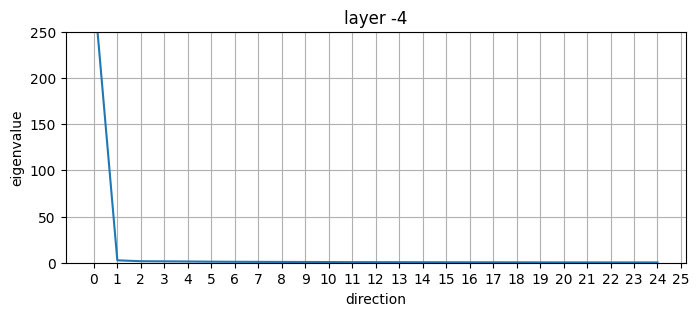

Layer: -3, Condition Number: 2.30e+14, Stable Rank: 1.00, Top k (0.8): 1, Participation Ratio: 1.02, eRank Entropy: 1.08
[2.2953481e+02 1.5105910e+00 6.8427736e-01 2.9929301e-01 4.5740489e-02
 1.9344710e-02 5.2392762e-03 9.8757213e-04 3.1838738e-04 2.3609283e-04
 1.5477728e-04 1.3642028e-04 1.3060754e-04 1.0161442e-04 8.7180306e-05
 8.1974780e-05 6.1199993e-05 5.9674378e-05 5.0096089e-05 2.5854140e-05
 1.3456635e-05 1.1016462e-05 9.9132831e-06 9.9019526e-06 9.7074499e-06]


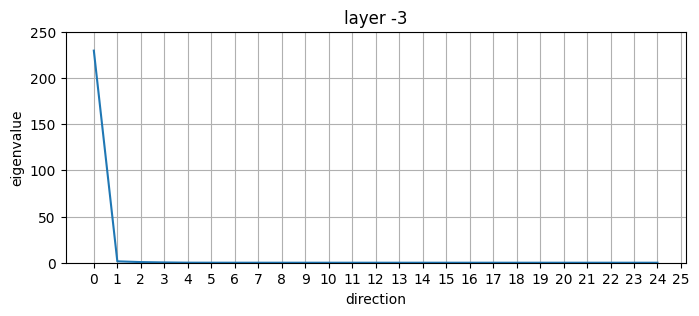

Layer: -2, Condition Number: 1.26e+13, Stable Rank: 8.22, Top k (0.8): 81, Participation Ratio: 78.22, eRank Entropy: 130.41
[12.574215  10.60718    9.3831625  8.061584   7.9042916  7.453405
  7.2398996  6.860491   6.8088884  6.324399   5.803956   5.6627984
  5.3877077  5.2919765  4.962674   4.7053213  4.6034427  4.449373
  4.398113   4.318546   4.2343664  4.0158734  3.8360739  3.7130263
  3.597387 ]


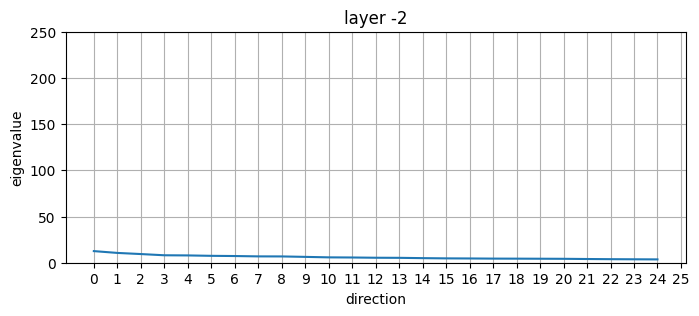

Layer: -1, Condition Number: 2.63e+14, Stable Rank: 1.00, Top k (0.8): 1, Participation Ratio: 1.03, eRank Entropy: 1.10
[2.6280753e+02 3.3429487e+00 1.1514428e+00 1.8845031e-04 1.0952223e-04
 1.0760150e-04 9.3413175e-05 8.6150168e-05 6.3700150e-05 6.3259831e-05
 4.3308246e-05 2.0968961e-05 1.4473975e-05 8.9554042e-06 8.4245858e-06
 5.6380959e-06 4.3466507e-06 4.0207774e-06 3.5112580e-06 3.4816246e-06
 3.4453547e-06 3.4199488e-06 2.9218108e-06 2.2576100e-06 2.0517809e-06]


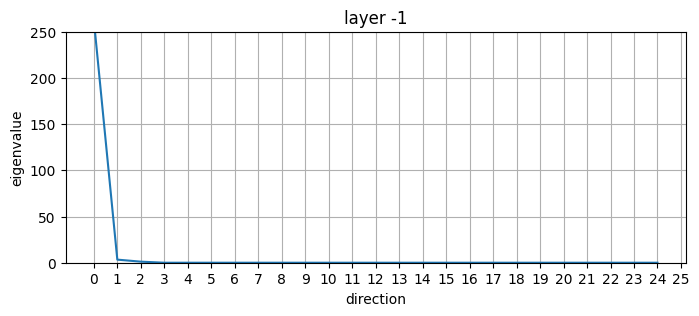

In [10]:
all_dict = controllers["Cam"].all_agop

cam_pr = {}
cam_fixed = {}
cam_ktau = {}

tau = 0.8
cutoff = 0.5

for i in all_dict:
    M = all_dict[i].detach().cpu().numpy()

    stats = spectral_indicators(M, tau=tau)
    print(f"Layer: {i}, Condition Number: {stats['condition_number_2']:.2e}, Stable Rank: {stats['stable_rank']:.2f}, Top k ({tau}): {stats['k_at_tau']}, Participation Ratio: {stats['participation_ratio']:.2f}, eRank Entropy: {stats['effective_rank_entropy']:.2f}")

    cam_pr[i] = math.ceil(stats['participation_ratio'])
    cam_ktau[i] = stats['k_at_tau']

    egv = stats['eigenvalues_desc']
    cam_fixed[i] = find_min_ind(egv, cutoff)

    print(egv[:25])

    plt.figure(figsize=(8, 3))
    plt.plot(egv[:25])
    plt.ylim(0.0, 250.0)
    plt.xticks(np.arange(0, 26, 1.0))
    plt.title(f"layer {i}")
    plt.xlabel("direction")
    plt.ylabel("eigenvalue")
    plt.grid(True)
    plt.show()

    # break


In [ ]:
all_dict = controllers["Isaac"].all_agop

isaac_pr = {}

tau = 0.98

for i in all_dict:
    M = all_dict[i].detach().cpu().numpy()

    stats = spectral_indicators(M, tau=tau)
    print(f"Layer: {i}, Condition Number: {stats['condition_number_2']:.2e}, Stable Rank: {stats['stable_rank']:.2f}, Top k ({tau}): {stats['k_at_tau']}, Participation Ratio: {stats['participation_ratio']:.2f}, eRank Entropy: {stats['effective_rank_entropy']:.2f}")

    isaac_pr[i] = math.ceil(stats['participation_ratio'])

    pl = stats['eigenvalues_desc'][:25]
    print(pl)

    # plt.figure(figsize=(8, 3))
    # plt.plot(pl)
    # plt.ylim(0.0, 250.0)
    # plt.xticks(np.arange(0, 26, 1.0))
    # plt.title(f"layer {i}")
    # plt.xlabel("direction")
    # plt.ylabel("eigenvalue")
    # plt.grid(True)
    # plt.show()

Layer: -1, Condition Number: 2.21e+14, Stable Rank: 1.16, Top k (0.98): 271, Participation Ratio: 6.69, eRank Entropy: 30.73
[220.87872    69.39268    36.04814    22.385315   15.6952715  11.543102
   9.678125    8.312505    7.3399334   7.165754    6.7725043   6.1410084
   5.511782    4.9858613   4.7322206   4.1287336   3.9515736   3.6618133
   3.6108043   3.4845812   3.1585774   3.0614996   2.9214597   2.7913666
   2.6785614]
Layer: -2, Condition Number: 3.79e+13, Stable Rank: 1.22, Top k (0.98): 286, Participation Ratio: 10.93, eRank Entropy: 52.02
[37.93732    14.01834     5.3088703   4.6232514   3.875273    2.8942502
  2.7430995   2.5025196   2.046915    1.8426486   1.718948    1.5472089
  1.4453049   1.3600662   1.2893131   1.1943046   1.1743728   1.0544627
  1.0293924   0.9906174   0.8999441   0.8733547   0.8569161   0.84234446
  0.8021517 ]
Layer: -3, Condition Number: 2.92e+13, Stable Rank: 1.21, Top k (0.98): 287, Participation Ratio: 9.73, eRank Entropy: 46.59
[29.213083   10.

In [ ]:
# emotion = "love"
# # emotion = "hate"

# raw_inputs = [
#     # f"Write a review for any movie.",
#     # f"Write a short poem.",
#     f"Write a sample review for a restaurant.",
#     f"Write a sample review for a movie.",
#     f"Write a sample review for a dance performance.",
#     # f"Write a sample review for a good restaurant.",
#     # f"Write a sample review for a good movie.",
#     # f"Write a sample review for a good dance performance.",
# ]
# inputs = [controller.format_prompt(x) for x in raw_inputs]

# num_new_tokens = 200
# controller = controllers[emotion]

# # coef=0.4 #llama 
# # coef=0.6
# # coef=0.9


# # coef = 0.5
# coef = 1.0
# # coef = 2.0

# top_m = 20
# # 20 with all layers works for restaurant

# prefill_last_token_only = False

# # layers = list(range(-5, -31, -1))
# layers = list(range(-5, -32, -1))

# gens=[]
# print()
# for i in inputs:
#     print("Prompt:", i)
#     print("===== No Control =====")
#     print(controller.generate(
#             i, 
#             max_new_tokens=num_new_tokens, 
#             do_sample=False,
#         ).replace(i, "")
#     )
#     print()
    
#     # print(f"===== + {emotion} Control (normal) =====")
#     # gen = controller.generate(
#     #     i, 
#     #     layers_to_control=layers, 
#     #     control_coef=coef, 
#     #     max_new_tokens=num_new_tokens, 
#     #     do_sample=False
#     # ).replace(i, "")
#     # gens.append(gen)

#     print(f"===== + {emotion} Control (anti) =====")
#     gen = controller.generate(
#         i, 
#         layers_to_control=layers, 
#         control_coef=coef, 
#         max_new_tokens=num_new_tokens, 
#         do_sample=False,
#         # do_sample=True,
#         # ----------------------
#         component_idx=top_m, 
#         anti=True, 
#         last=prefill_last_token_only,
#         # last=True,
#     # ).replace(i, "")
#     )
#     # gens.append(gen)
#     gens.append("="*50 + "\n" + f"{emotion}, coef:{coef}, prefill last:{prefill_last_token_only}, {layers} "+ "\n" + "="*50 + "\n" + gen)

#     print()
#     print(gens[-1])
#     print()
#     print()

# # for line in gens:
# #     print(f"{line}\n")

In [12]:
raw_inputs = [
    f"What is Isaac Newton known for?",
    f"Why is Isaac Newton so famous?",
    f"What are Isaac Newton's achievements?",
    f"Tell me about newton.",
    f"Tell me about Isaac Newton.",
    f"What did Isaac Newton contribute to motion?",
    # ----------------------------------------
    f"What is Cam Newton known for?",
    f"Why is Cam Newton so famous?",
    f"What are Cam Newton's achievements?",
    f"Tell me about Cam Newton.",
    f"What did Cam Newton contribute to sports?",
    # --------------------------------------
    f"Give a list of 5 most famous physicists.",
    f"Give a list of 5 most famous english physicists.",
    f"Give a list of physicists that worked on graviation.",
    f"Give a list of 5 most famous NFL quarterbacks that played for Carolina Panthers.",
    f"Give a list of famous African-American NFL quarterbacks.",
    f"Give a list of famous NFL quarterbacks born in Georgia.",
    # f"Tell me about newton.",
    # f"What is Newton known for?",
    # f"What is Olivia Newton known for?",
    # f"What is Huey Newton known for?",
    # --------------------------------------
    "Tell me about ships",
    "What is the Central Limit Theorem?",
]

In [ ]:
cam_top_m = cam_pr
# cam_top_m = {k: min(3 * cam_pr[k], 70) for k in cam_pr}
# cam_top_m = {k: 2 * cam_pr[k] for k in cam_pr}
# cam_top_m = {k: cam_fixed[k] for k in cam_fixed}
# cam_top_m = {k: min(cam_fixed[k], 25) for k in cam_fix}



print(cam_pr)
print(cam_ktau)
#
# 
# print({k: 2 * cam_pr[k] for k in cam_pr})
# print(cam_top_m)

{-31: 3, -30: 4, -29: 2, -28: 3, -27: 3, -26: 4, -25: 5, -24: 5, -23: 5, -22: 6, -21: 6, -20: 5, -19: 7, -18: 9, -17: 10, -16: 3, -15: 7, -14: 2, -13: 2, -12: 4, -11: 5, -10: 5, -9: 4, -8: 4, -7: 3, -6: 6, -5: 3, -4: 5, -3: 9, -2: 6, -1: 4}
{-31: 3, -30: 5, -29: 2, -28: 5, -27: 4, -26: 6, -25: 5, -24: 6, -23: 6, -22: 7, -21: 7, -20: 6, -19: 33, -18: 34, -17: 31, -16: 2, -15: 18, -14: 2, -13: 2, -12: 3, -11: 4, -10: 10, -9: 4, -8: 6, -7: 7, -6: 11, -5: 6, -4: 10, -3: 13, -2: 4, -1: 4}


In [76]:
isaac_top_m = {k: 2 * isaac_pr[k] for k in isaac_pr}

In [ ]:
# raw_inputs = [
#     f"Give a list of 5 most famous physicists.",
#     f"Give a list of 5 most famous NFL quarterbacks that played for Carolina Panthers.",
# ]

In [14]:
# newton_type = "Isaac"
newton_type = "Cam"

manual_directions = top_dirs_cam


inputs = [controller.format_prompt(x) for x in raw_inputs]

num_new_tokens = 200
controller = controllers[newton_type]


# 25 [-16, -19, -20, -21, -22, -23, -24, -25, -26] Cam isaac_cam_300_3_0


# top_m = 0
# top_m = 1
# top_m = 5
# top_m = 10
top_m = 15
# top_m = 25

# top_m = cam_top_m
# top_m = isaac_top_m
# top_m = {k: 2 * isaac_pr[k] for k in isaac_pr}
# top_m = {k: min(2 * isaac_pr[k], 25) for k in isaac_pr}

prefill_last_token_only = False

# coef=0.4 #llama 
# coef=0.9

# coef = 0.5
coef = 1.0
# coef = 1.7

# layers = list(range(-5, -31, -1))
layers = list(range(-1, -32, -1))
# layers = [-16, -19, -20, -21, -22, -23, -24, -25, -26]

# layers = [-7, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26]
# layers = [-7, -15, -17, -18]
# layers = [-7, -15, -16, -17, -18, -19, -20, -21, -22]
# layers = [-7, -15, -16, -17, -18, -19, -20, -21, -22, -28]


gens=[]
print()
for i in inputs:
    print("Prompt:", i)
    print("===== No Control =====")
    print(controller.generate(
            i, 
            max_new_tokens=num_new_tokens, 
            do_sample=False,
        ).replace(i, "")
    )
    print()
    
    # print(f"===== + {newton_type} Control (normal) =====")
    # gen = controller.generate(
    #     i, 
    #     layers_to_control=layers, 
    #     control_coef=coef, 
    #     max_new_tokens=num_new_tokens, 
    #     do_sample=False
    # # ).replace(i, "")
    # )
    # gens.append(gen)

    print(f"===== + {newton_type} Control (anti) =====")
    gen = controller.generate(
        i, 
        layers_to_control=layers, 
        control_coef=coef, 
        max_new_tokens=num_new_tokens, 
        do_sample=False,
        # ----------------------
        component_idx=top_m,
        manual_directions=manual_directions,
        anti="yes", 
        last=prefill_last_token_only,
        # last=True,
    # ).replace(i, "")
    )
    # gens.append(gen)
    # gens.append("="*50 + "\n" + f"{newton_type}, coef:{coef}, prefill last:{prefill_last_token_only}, {layers} "+ "\n" + "="*50 + "\n" + gen)
    gens.append("="*50 + "\n" + f"{newton_type}, coef:{coef}, prefill last:{prefill_last_token_only}, {layers} "+ "\n" + "="*50 + "\n" + gen)

    print()
    print(gens[-1])
    print()
    print()


# for line in gens:
#     print(f"{line}\n")


Prompt: <|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

<|eot_id|><|start_header_id|>user<|end_header_id|>

What is Isaac Newton known for?<|eot_id|>
===== No Control =====
<|start_header_id|>assistant<|end_header_id|>

Sir Isaac Newton (1643-1727) was a renowned English mathematician, physicist, astronomer, and scientist who made significant contributions to various fields. He is widely recognized as one of the most influential scientists in history. Here are some of the key things he is known for:

1. **Laws of Motion**: Newton formulated three laws of motion that describe how objects move and respond to forces. These laws are still widely used today in physics and engineering.
2. **Universal Gravitation**: Newton's law of universal gravitation states that every point mass attracts every other point mass by a force acting along the line intersecting both points. This law explained the motion of planets, moon

In [14]:
with open("../outputs/" + "misc" + "/" + "isaac_iterative1" + ".txt", "a") as f:
    for line in gens:
        f.write(f"{line}\n")

In [16]:
lh = find_lingering_forward_hooks(language_model)

Success: No lingering forward hooks found in the model.


In [ ]:
# # newton_type = "Isaac"
# newton_type = "Cam"

# raw_inputs = [
#     f"What is Isaac Newton known for?",
#     f"Why is Isaac Newton so famous?",
#     f"What are Isaac Newton's achievements?",
#     # f"Why is Newton the phycisist so famous?",
#     # f"Tell me about newton.",
#     f"Tell me about Isaac Newton.",
#     f"What did Isaac Newton contribute to motion?",
#     # ----------------------------------------
#     f"What is Cam Newton known for?",
#     f"Why is Cam Newton so famous?",
#     f"What are Cam Newton's achievements?",
#     # f"Tell me about the famous sportsman who was the quarterback for the Carolina Panthers of the National Football League (NFL), his surname was Newton.",
#     # f"Why is Newton the sportsman so famous?",
#     f"Tell me about Cam Newton.",
#     f"What did Cam Newton contribute to sports?",
#     # --------------------------------------
#     # f"Tell me about newton.",
#     # f"What is Newton known for?",
#     # f"What is Olivia Newton known for?",
#     # f"What is Huey Newton known for?",
#     "Tell me about ships",
#     "What is the Central Limit Theorem?",
# ]
# inputs = [controller.format_prompt(x) for x in raw_inputs]

# num_new_tokens = 200
# controller = controllers[newton_type]

# # coef=0.4 #llama 
# # coef=0.9


# coef = 1.0
# # coef = 0.5
# # coef = 1.1

# # top_m = 20
# # top_m_list = [10, 15, 20, 25]
# # top_m_list = [30, 40]
# top_m_list = [cam_top_m, ]

# prefill_last_token_only = False


# # layers_list = [[-3,-4],]

# layers_list = [list(range(-1, -32, -1)),]

# # layers_list = [
# #     list(range(-1, -32, -1)), list(range(-1, -31, -1)), list(range(-2, -32, -1)),
# #     list(range(-1, -6, -1)), list(range(-2, -7, -1)),
# #     list(range(-6, -11, -1)), list(range(-11, -16, -1)), list(range(-16, -21, -1)), 
# #     list(range(-21, -26, -1)), list(range(-26, -31, -1)), list(range(-26, -32, -1)), 
# # ]

# # layers_list = [
# #     list(range(-1, -31, -1)), list(range(-1, -6, -1)), 
# #     list(range(-6, -11, -1)), list(range(-11, -16, -1)), list(range(-16, -21, -1)), 
# #     list(range(-21, -26, -1)), list(range(-26, -31, -1)),
# # ]

# # layers_list = [
# #     list(range(-1, -11, -1)), list(range(-11, -21, -1)), list(range(-21, -31, -1)), 
# # ]

# # layers_list = [
# #     list(range(-1, -16, -1)), list(range(-16, -32, -1)), 
# # ]


# # folder_name = "../outputs/" + "5_last"
# # folder_name = "../outputs/" + f"{newton_type}/5_all_m{top_m}_coef{coef}"

# # os.makedirs(folder_name, exist_ok=True)


# for top_m in top_m_list:
#     # folder_name = "../outputs/" + f"{newton_type}/5_all_m{top_m}_coef{coef}"

#     # folder_name = "../outputs/" + f"temp/all_m(cam_fixed)_coef{coef}"
#     folder_name = "../outputs/" + f"temp/all_m(cam_pr)_coef{coef}"

#     os.makedirs(folder_name, exist_ok=True)

#     ind = 0

#     for layers in tqdm(layers_list):
#         ind += 1
#         gens=[]
#         for i in inputs:
#             # print(f"===== + {newton_type} Control (anti) =====")
#             gen = controller.generate(
#                 i, 
#                 layers_to_control=layers, 
#                 control_coef=coef, 
#                 max_new_tokens=num_new_tokens, 
#                 do_sample=False,
#                 # ----------------------
#                 component_idx=top_m, 
#                 anti=True, 
#                 last=prefill_last_token_only,
#             )
#             # gens.append(gen)
#             gens.append("="*50 + "\n" + f"{newton_type}, coef:{coef}, prefill last:{prefill_last_token_only}, {layers} "+ "\n" + "="*50 + "\n" + gen)

#         with open(folder_name + "/" + str(ind) + ".txt", "a") as f:
#             for line in gens:
#                 f.write(f"{line}\n")

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:34<00:00, 34.25s/it]


In [36]:
print("Done")

Done


In [31]:
from scipy.linalg import orth
import numpy as np

In [32]:
c = torch.rand((300, 4096))
h = torch.rand((1, 1, 4096))
hp = torch.rand((1, 38, 4096))

In [33]:
print(c.shape)
print(c[:200].shape)
print(h.shape)
print(hp.shape)

torch.Size([300, 4096])
torch.Size([200, 4096])
torch.Size([1, 1, 4096])
torch.Size([1, 38, 4096])


In [14]:
c_np = c.detach().cpu().numpy() # [300, 4096]
o_np = orth(c_np.T)
o = torch.from_numpy(o_np).to(device=c.device, dtype=c.dtype).contiguous()

print(o.shape)

torch.Size([4096, 300])


In [15]:
print((h @ o).shape)

proj = (h @ o) @ o.T

print(proj.shape)

torch.Size([1, 1, 300])
torch.Size([1, 1, 4096])


In [16]:
h_projected = h - proj

t = h_projected @ o
print(t.shape)
# print(t[0][0])

torch.Size([1, 1, 300])


In [17]:
zeros_tensor = torch.zeros_like(t[0][0])

print(torch.allclose(t[0][0], zeros_tensor, atol=3e-6))

False


In [18]:
l = proj @ o
k = h @ o
# print(l.shape)
# print(l[0][0])
print(torch.allclose(l,k, atol=3e-6))

True


In [19]:
print((hp @ o).shape)

projp = (hp @ o) @ o.T

print(projp.shape)

torch.Size([1, 38, 300])
torch.Size([1, 38, 4096])


In [20]:
h_projectedp = hp - projp

tp = h_projectedp @ o
print(tp.shape)

torch.Size([1, 38, 300])


In [21]:
zeros_tensorp = torch.zeros_like(tp)

print(torch.allclose(tp, zeros_tensorp, atol=8e-6))

True
